In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [2]:
df = pd.read_csv("../data/house_price_dataset_india_12k.csv")

In [3]:
df.head()

,House_ID,City,Locality_Tier,BHK,Bathrooms,Super_Area_sqft,Carpet_Area_sqft,Floor_No,Total_Floors,Property_Age_years,...,Furnishing,Lift,Gated_Society,Distance_to_Metro_km,Distance_to_CityCenter_km,Nearby_School_km,Nearby_Hospital_km,Crime_Rate_Index,Market_Price_INR,Price_per_sqft_INR
0,1,Hyderabad,Mid,3,4,957.3,809.1,11,15,8,...,Semi-Furnished,1,0,2.44,20.76,1.77,3.52,32.4,7736451,8082
1,2,Bangalore,Budget,2,3,883.3,711.7,13,16,13,...,Semi-Furnished,1,0,0.48,17.56,2.82,4.86,66.3,5771877,6534
2,3,Pune,Premium,3,4,1331.5,1087.1,13,15,7,...,Unfurnished,1,1,2.76,9.73,0.20,1.75,23.3,14688106,11031
3,4,Mumbai,Premium,3,4,997.6,801.0,7,19,10,...,Semi-Furnished,1,1,1.12,13.15,0.27,0.61,18.8,19094254,19140
4,5,Pune,Mid,2,2,967.6,707.6,5,16,6,...,Unfurnished,1,1,2.46,14.07,3.34,3.93,41.0,7592420,7847


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   House_ID                   12000 non-null  int64  
 1   City                       12000 non-null  object 
 2   Locality_Tier              12000 non-null  object 
 3   BHK                        12000 non-null  int64  
 4   Bathrooms                  12000 non-null  int64  
 5   Super_Area_sqft            12000 non-null  float64
 6   Carpet_Area_sqft           12000 non-null  float64
 7   Floor_No                   12000 non-null  int64  
 8   Total_Floors               12000 non-null  int64  
 9   Property_Age_years         12000 non-null  int64  
 10  Parking                    12000 non-null  int64  
 11  Furnishing                 12000 non-null  object 
 12  Lift                       12000 non-null  int64  
 13  Gated_Society              12000 non-null  int

In [5]:
df.describe()

,House_ID,BHK,Bathrooms,Super_Area_sqft,Carpet_Area_sqft,Floor_No,Total_Floors,Property_Age_years,Parking,Lift,Gated_Society,Distance_to_Metro_km,Distance_to_CityCenter_km,Nearby_School_km,Nearby_Hospital_km,Crime_Rate_Index,Market_Price_INR,Price_per_sqft_INR
count,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,1.200000e+04,12000.000000
mean,6000.50000,2.304167,2.536083,1018.260342,763.563383,7.599000,15.232667,8.615917,0.640083,0.924167,0.588667,2.153820,14.101654,2.807817,3.059477,41.756825,1.020406e+07,9689.409667
std,3464.24595,0.934909,1.102482,379.974189,291.095491,5.685352,5.707604,5.374815,0.479996,0.264742,0.492096,1.817501,7.149948,1.352786,1.507851,13.716940,6.707595e+06,4279.861543
min,1.00000,1.000000,1.000000,350.000000,250.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.200000,0.500000,0.200000,0.300000,5.000000,1.356119e+06,2480.000000
25%,3000.75000,2.000000,2.000000,781.800000,569.700000,3.000000,11.000000,4.000000,0.000000,1.000000,0.000000,0.410000,9.000000,1.840000,1.990000,32.200000,5.586925e+06,6562.750000
50%,6000.50000,2.000000,2.000000,950.500000,715.550000,7.000000,15.000000,8.000000,1.000000,1.000000,1.000000,1.830000,14.010000,2.800000,3.000000,41.800000,8.558740e+06,8763.000000
75%,9000.25000,3.000000,3.000000,1226.300000,915.200000,11.000000,19.000000,12.000000,1.000000,1.000000,1.000000,3.340000,19.000000,3.760000,4.080000,51.400000,1.304248e+07,11980.000000
max,12000.00000,5.000000,7.000000,3010.400000,2285.900000,32.000000,38.000000,33.000000,1.000000,1.000000,1.000000,11.600000,39.800000,8.710000,8.810000,85.400000,5.755283e+07,22626.000000


In [6]:
df.isnull().sum()

House_ID                     0
City                         0
Locality_Tier                0
BHK                          0
Bathrooms                    0
Super_Area_sqft              0
Carpet_Area_sqft             0
Floor_No                     0
Total_Floors                 0
Property_Age_years           0
Parking                      0
Furnishing                   0
Lift                         0
Gated_Society                0
Distance_to_Metro_km         0
Distance_to_CityCenter_km    0
Nearby_School_km             0
Nearby_Hospital_km           0
Crime_Rate_Index             0
Market_Price_INR             0
Price_per_sqft_INR           0
dtype: int64

In [7]:
df.duplicated().sum()

0

In [8]:
df.columns

Index(['House_ID', 'City', 'Locality_Tier', 'BHK', 'Bathrooms',
       'Super_Area_sqft', 'Carpet_Area_sqft', 'Floor_No', 'Total_Floors',
       'Property_Age_years', 'Parking', 'Furnishing', 'Lift', 'Gated_Society',
       'Distance_to_Metro_km', 'Distance_to_CityCenter_km', 'Nearby_School_km',
       'Nearby_Hospital_km', 'Crime_Rate_Index', 'Market_Price_INR',
       'Price_per_sqft_INR'],
      dtype='object')

In [9]:
df["BHK"].max()

5

In [10]:
df.drop("House_ID", axis=1, inplace=True)

In [11]:
df.shape

(12000, 20)

In [12]:
#encoding of categorical data

cat_cols=['City', 'Locality_Tier','Furnishing']

#nemerical columns

num_cols = ["BHK","Bathrooms","Super_Area_sqft","Carpet_Area_sqft","Property_Age_years","Distance_to_Metro_km","Crime_Rate_Index","Price_per_sqft_INR"
]

In [13]:
#Univariate Analysis
#sns.histplot(df['Market_Price_INR'], kde=True)
df['Market_Price_INR'].dtype

dtype('int64')

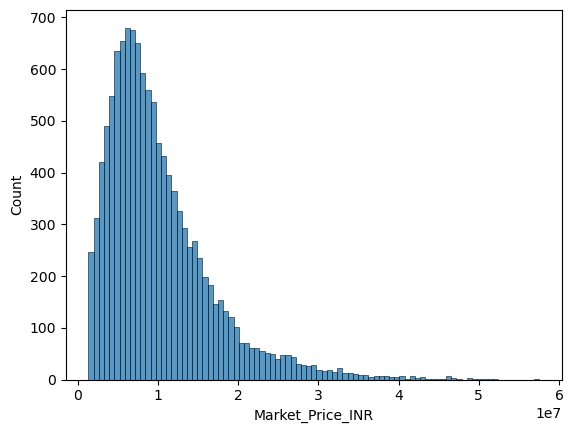

In [14]:
sns.histplot(df['Market_Price_INR'])
plt.show()

In [15]:
df['Market_Price_INR'].describe()

#convert price into crores
df['Price_Crore'] = df['Market_Price_INR'] / 10000000

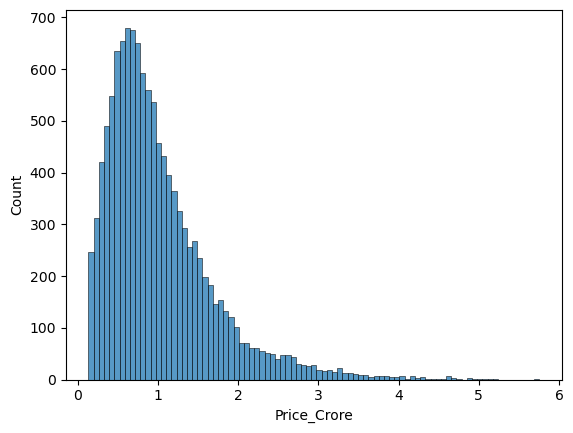

In [16]:
#to know prices of houses
sns.histplot(df['Price_Crore'])   #left skewed
plt.show()

<AxesSubplot:xlabel='BHK', ylabel='count'>

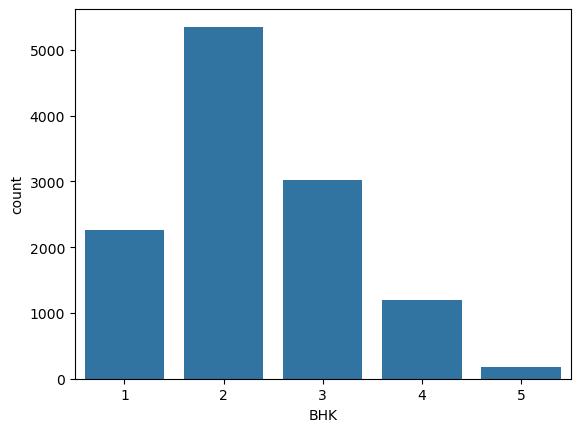

In [17]:
#type of houses
sns.countplot(x=df['BHK'])

<AxesSubplot:xlabel='City', ylabel='count'>

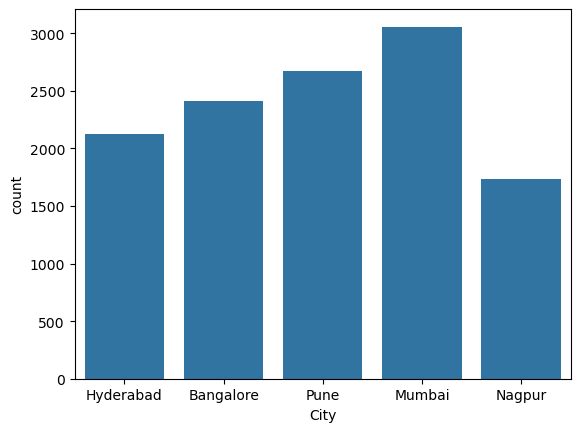

In [18]:
#city distribution
sns.countplot(x=df['City'])

<AxesSubplot:xlabel='Furnishing', ylabel='count'>

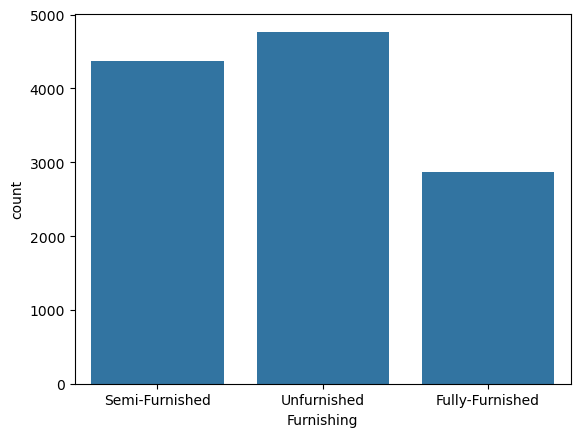

In [19]:
sns.countplot(x=df['Furnishing'])

<AxesSubplot:xlabel='Super_Area_sqft', ylabel='Market_Price_INR'>

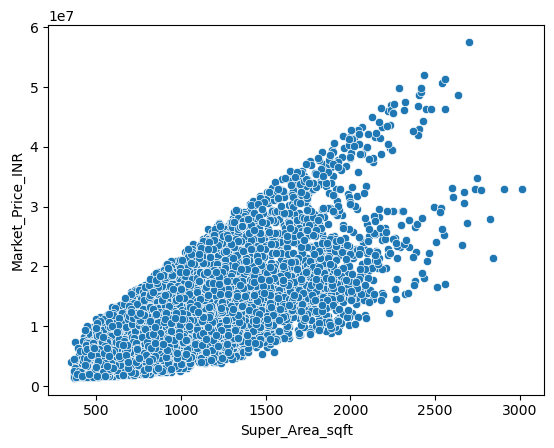

In [20]:
#AREA VS PRICE

sns.scatterplot(
    x=df['Super_Area_sqft'],
    y=df['Market_Price_INR']
)

<AxesSubplot:xlabel='BHK', ylabel='Market_Price_INR'>

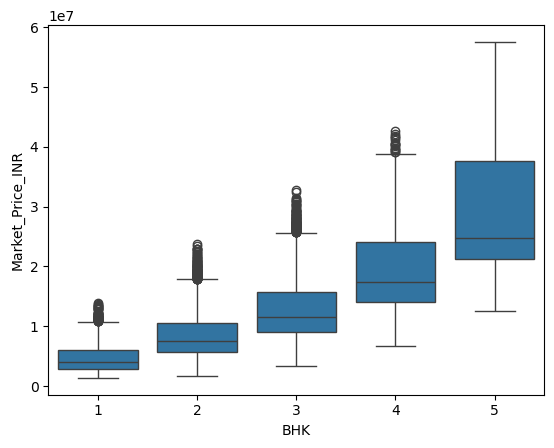

In [21]:
sns.boxplot(
    x=df['BHK'],
    y=df['Market_Price_INR']
)

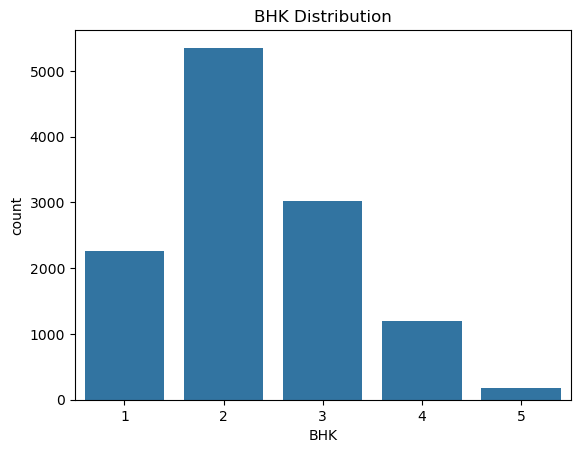

In [22]:
sns.countplot(x=df['BHK'])  #to check which bhk are more

plt.title("BHK Distribution")

plt.show()

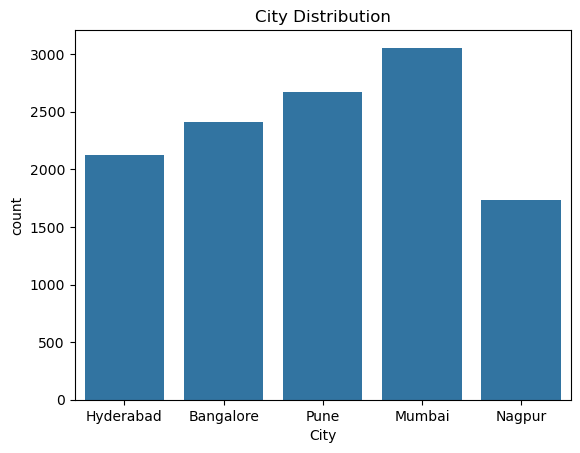

In [23]:
sns.countplot(x=df['City'])  #Which cities dominate dataset?

plt.title("City Distribution")

plt.show()

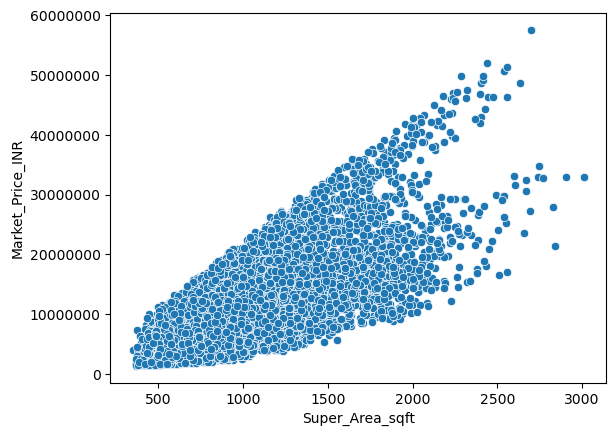

In [24]:
sns.scatterplot(
    x=df['Super_Area_sqft'],
    y=df['Market_Price_INR']
)

plt.ticklabel_format(style='plain', axis='y')

plt.show()

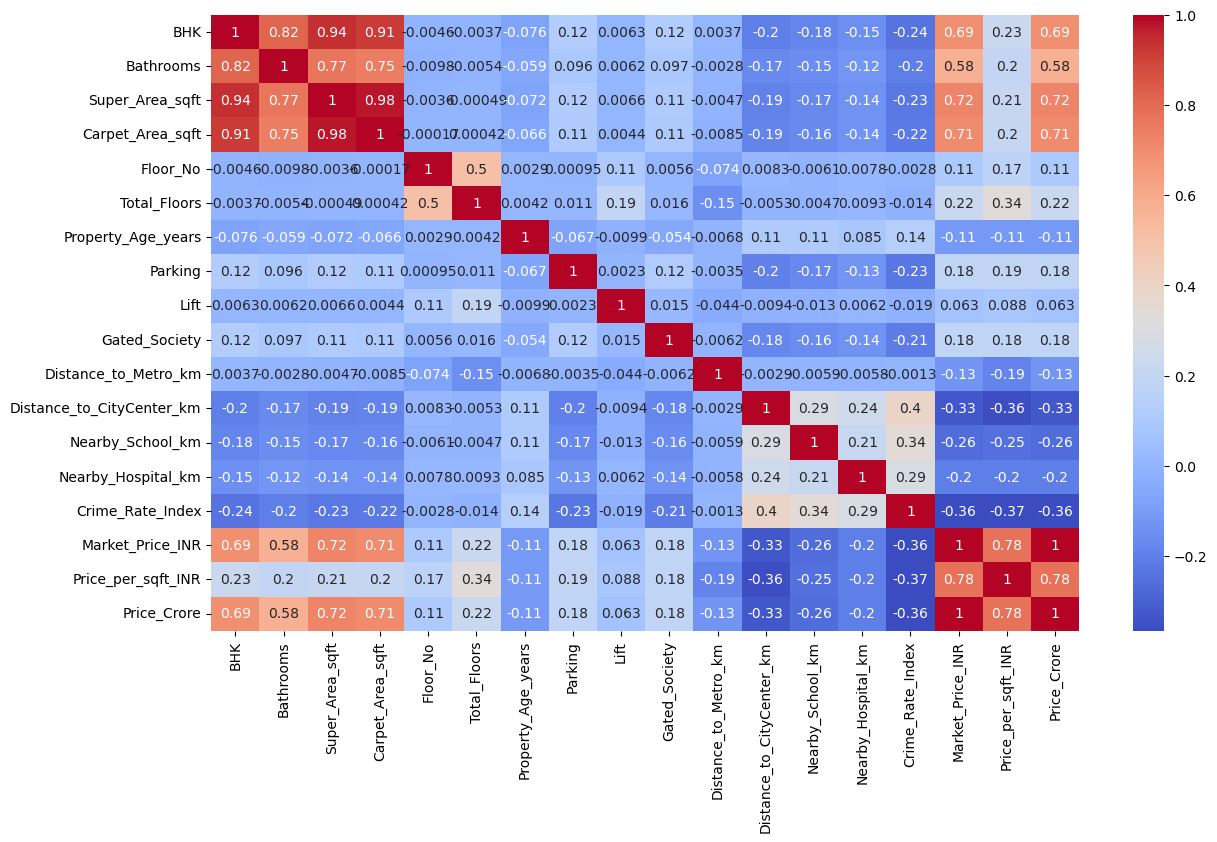

In [25]:
#How strongly two numerical variables are related. from -1 to 1

plt.figure(figsize=(14,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.show()

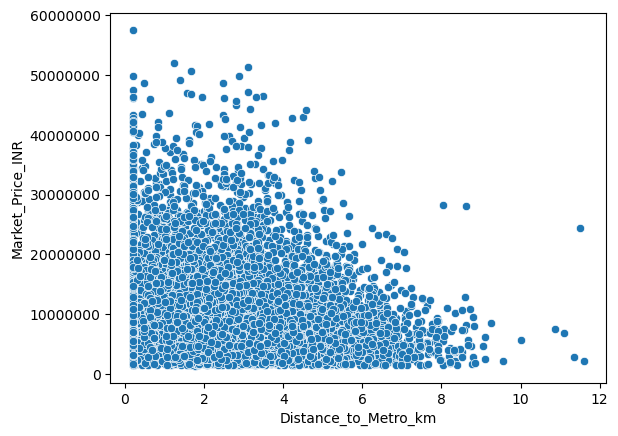

In [26]:
sns.scatterplot(
    x=df['Distance_to_Metro_km'],
    y=df['Market_Price_INR']
)

plt.ticklabel_format(style='plain', axis='y')

plt.show()

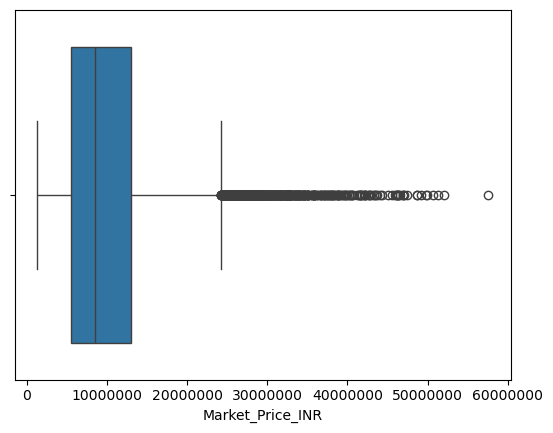

In [27]:
sns.boxplot(x=df['Market_Price_INR'])

plt.ticklabel_format(style='plain', axis='x')

plt.show()

In [28]:
#Feature Engineering + Preprocessing

In [29]:
df.drop("House_ID", axis=1, inplace=True)  #drop unnecessary columns

KeyError: "['House_ID'] not found in axis"

In [ ]:
df.dtypes

In [ ]:
cat_cols = [
    'City',
    'Locality_Tier',   #Categorical Columns
    'Furnishing'
]

In [ ]:
#Create Luxury Score -> Feature Engineering

df['Luxury_Score'] = (
    df['Parking'] +
    df['Lift'] +
    df['Gated_Society']
)


In [ ]:
#Price Per Bedroom Feature

df['Price_per_BHK'] = (
    df['Market_Price_INR'] / df['BHK']
)

In [ ]:
df['Age_Category'] = pd.cut(
    df['Property_Age_years'],
    bins=[0,5,15,100],
    labels=['New','Medium','Old']
)

In [ ]:
df.head()  #Luxury_Score,Price_per_BHK,Age_Category ->new columns

In [ ]:
df = pd.get_dummies(df,columns=['City','Locality_Tier','Furnishing','Age_Category'],drop_first=True)

In [30]:
#df.dtypes
df.drop("Price_per_sqft_INR", axis=1, inplace=True)

In [31]:
df.info() #ALL columns should be numeric.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   City                       12000 non-null  object 
 1   Locality_Tier              12000 non-null  object 
 2   BHK                        12000 non-null  int64  
 3   Bathrooms                  12000 non-null  int64  
 4   Super_Area_sqft            12000 non-null  float64
 5   Carpet_Area_sqft           12000 non-null  float64
 6   Floor_No                   12000 non-null  int64  
 7   Total_Floors               12000 non-null  int64  
 8   Property_Age_years         12000 non-null  int64  
 9   Parking                    12000 non-null  int64  
 10  Furnishing                 12000 non-null  object 
 11  Lift                       12000 non-null  int64  
 12  Gated_Society              12000 non-null  int64  
 13  Distance_to_Metro_km       12000 non-null  flo

In [32]:
#Model Building

In [33]:
X = df.drop("Market_Price_INR", axis=1)

y = df["Market_Price_INR"]

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [35]:
X_train.shape

(9600, 19)

In [36]:
X_test.shape

(2400, 19)

In [40]:
lr = LinearRegression()

In [41]:
lr.fit(X_train, y_train)

ValueError: could not convert string to float: 'Mumbai'

In [42]:
lr_preds = lr.predict(X_test)

ValueError: could not convert string to float: 'Hyderabad'

In [43]:
mae = mean_absolute_error(y_test, lr_preds)
print(mae)

#model is off by 11.. lakhs

NameError: name 'lr_preds' is not defined

In [44]:
r2 = r2_score(y_test, lr_preds)

print(r2)

#Closer to: 1 means better predictions.

NameError: name 'lr_preds' is not defined

In [45]:
#Random Forest Model

In [ ]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [ ]:
rf.fit(X_train, y_train)

In [ ]:
rf_preds = rf.predict(X_test)

In [ ]:
print(mean_absolute_error(y_test, rf_preds))

print(r2_score(y_test, rf_preds))

In [ ]:
#Random Forest performs MUCH better than Linear Regression for housing data

In [ ]:
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

In [ ]:
xgb.fit(X_train, y_train)

In [ ]:
xgb_preds = xgb.predict(X_test)

In [ ]:
print(mean_absolute_error(y_test, xgb_preds))

print(r2_score(y_test, xgb_preds))

In [ ]:
#XGBoost > Random Forest > Linear Regression

In [ ]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'XGBoost'
    ],
    
    'R2 Score': [
        r2_score(y_test, lr_preds),
        r2_score(y_test, rf_preds),
        r2_score(y_test, xgb_preds)
    ],
    
    'MAE': [
        mean_absolute_error(y_test, lr_preds),
        mean_absolute_error(y_test, rf_preds),
        mean_absolute_error(y_test, xgb_preds)
    ]
})

results

In [ ]:
#This is Called Target Leakage
#Definition:

#Feature contains information that would not realistically be available at prediction time.

#Market Price≈Price per sqft×Area  --s0 remove that feature-> df.drop("Price_per_sqft_INR", axis=1, inplace=True)

In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
scores = cross_val_score(
    xgb,
    X,
    y,
    cv=5,
    scoring='r2'
)

In [ ]:
print(scores.mean())

In [301]:
#Build the Streamlit Frontend

In [302]:
import joblib

In [303]:
joblib.dump(xgb, "house_price_model.pkl")

['house_price_model.pkl']

In [365]:
#FOR FINAL DEPLOYEMENT

In [366]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

In [367]:
features = [
    'City',
    'Locality_Tier',
    'BHK',
    'Bathrooms',
    'Super_Area_sqft',
    'Carpet_Area_sqft',
    'Floor_No',
    'Total_Floors',
    'Property_Age_years',
    'Parking',
    'Furnishing',
    'Lift',
    'Gated_Society',
    'Distance_to_Metro_km',
    'Distance_to_CityCenter_km',
    'Nearby_School_km',
    'Nearby_Hospital_km',
    'Crime_Rate_Index'
]

X = df[features]

y = df['Market_Price_INR']

In [368]:
categorical_features = [
    'City',
    'Locality_Tier',
    'Furnishing'
]

In [369]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ],
    remainder='passthrough'
)

In [370]:
pipeline_model = Pipeline([
    (
        'preprocessor',
        preprocessor
    ),
    (
        'regressor',
        XGBRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=6,
            random_state=42
        )
    )
])

In [371]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [372]:
pipeline_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['City', 'Locality_Tier',
                                                   'Furnishing'])])),
                ('regressor',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=None, device=None,
                              early_stopping_rounds=Non...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=6, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=200, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [373]:
pipeline_model.predict(X_test[:2])

array([4807770., 5506954.], dtype=float32)

In [374]:
import joblib

joblib.dump(
    pipeline_model,
    "../models/house_price_model.pkl"
)

['../models/house_price_model.pkl']

In [375]:
loaded_model = joblib.load(
    "../models/house_price_model.pkl"
)

loaded_model.predict(X_test[:2])

array([4807770., 5506954.], dtype=float32)